## Carregamento da base

In [ ]:
import pandas as pd

df_varejo = pd.read_csv("Retail_Transactions_Dataset.csv", sep=',')
df_varejo.head(20)

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items
5,1000000005,2021-10-07 12:37:26,Joshua Frazier,"['Toothpaste', 'Chicken']",3,72.24,Cash,Houston,Supermarket,True,Retiree,Spring,Discount on Selected Items
6,1000000006,2023-01-08 10:40:03,Victoria Garrett,"['Honey', 'BBQ Sauce', 'Soda', 'Olive Oil', 'G...",4,5.28,Cash,Boston,Specialty Store,False,Student,Summer,Discount on Selected Items
7,1000000007,2020-09-03 12:39:59,Sydney Waller,"['Syrup', 'Trash Cans', 'Pancake Mix', 'Water'...",5,21.77,Debit Card,Chicago,Specialty Store,False,Young Adult,Winter,Discount on Selected Items
8,1000000008,2021-04-05 06:32:18,Kimberly Morgan,['Insect Repellent'],4,55.25,Mobile Payment,Los Angeles,Warehouse Club,False,Homemaker,Fall,NaN
9,1000000009,2021-07-08 10:08:59,Lori Conway,"['Soap', 'Baby Wipes', 'Soda']",7,31.21,Mobile Payment,Boston,Convenience Store,True,Young Adult,Winter,NaN


In [2]:
df_varejo.shape

(1000000, 13)

## Análise exploratória

In [3]:
#Analisando os tipos de dados
df_varejo.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  str    
 2   Customer_Name      1000000 non-null  str    
 3   Product            1000000 non-null  str    
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  str    
 7   City               1000000 non-null  str    
 8   Store_Type         1000000 non-null  str    
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  str    
 11  Season             1000000 non-null  str    
 12  Promotion          666057 non-null   str    
dtypes: bool(1), float64(1), int64(2), str(9)
memory usage: 218.6 MB


In [4]:
#Verificação de valores nulos
df_varejo.isnull().sum()

Transaction_ID            0
Date                      0
Customer_Name             0
Product                   0
Total_Items               0
Total_Cost                0
Payment_Method            0
City                      0
Store_Type                0
Discount_Applied          0
Customer_Category         0
Season                    0
Promotion            333943
dtype: int64

In [5]:
#Verificação de valores duplicados
df_varejo.duplicated().sum()

0

In [6]:
#Descrição estatística da coluna Total_Cost
df_varejo['Total_Cost'].describe()

count    1000000.000000
mean          52.455220
std           27.416989
min            5.000000
25%           28.710000
50%           52.420000
75%           76.190000
max          100.000000
Name: Total_Cost, dtype: float64

In [7]:
#Verificando a quantidade de valores únicos em cada coluna
df_varejo.nunique()

Transaction_ID       1000000
Date                  996337
Customer_Name         329738
Product               571947
Total_Items               10
Total_Cost              9501
Payment_Method             4
City                      10
Store_Type                 6
Discount_Applied           2
Customer_Category          8
Season                     4
Promotion                  2
dtype: int64

In [8]:
#Analisando os valores únicos de algumas colunas categóricas

df_varejo['Payment_Method'].unique()
#df_varejo['City'].unique()
#df_varejo['Store_Type'].unique()
#df_varejo['Customer_Category'].unique()
#df_varejo['Discount_Applied'].unique()
#df_varejo['Season'].unique()

<ArrowStringArray>
['Mobile Payment', 'Cash', 'Credit Card', 'Debit Card']
Length: 4, dtype: str

In [9]:
#Maior preço que alguém comprou e maior quantidade de itens comprados

#df_varejo["Total_Items"].max()
df_varejo["Total_Cost"].max()

100.0

In [10]:
#somar a quantidade de itens vendidos 
df_varejo["Total_Items"].sum()

5495941

In [11]:
#valor total de vendas
df_varejo["Total_Cost"].sum()

52455220.39999998

In [12]:
#Quantos itens cada Store_type vendeu 
df_varejo.groupby("Store_Type")["Total_Items"].sum()


Store_Type
Convenience Store    918049
Department Store     915635
Pharmacy             917729
Specialty Store      914950
Supermarket          915772
Warehouse Club       913806
Name: Total_Items, dtype: int64

In [13]:
#Quantos % representa do total de itens vendidos
soma_itens = df_varejo.groupby("Store_Type")["Total_Items"].sum()
print((soma_itens / soma_itens.sum() * 100).round(2))

Store_Type
Convenience Store    16.70
Department Store     16.66
Pharmacy             16.70
Specialty Store      16.65
Supermarket          16.66
Warehouse Club       16.63
Name: Total_Items, dtype: float64


In [14]:
#Qual o total de custo por Store_type.
df_varejo.groupby("Store_Type")["Total_Cost"].sum()

Store_Type
Convenience Store    8731901.36
Department Store     8731555.57
Pharmacy             8766679.01
Specialty Store      8701600.22
Supermarket          8763455.21
Warehouse Club       8760029.03
Name: Total_Cost, dtype: float64

In [15]:
#Qual o % do total de custos.
soma_custo = df_varejo.groupby("Store_Type")["Total_Cost"].sum()
print((soma_custo / soma_custo.sum() * 100).round(2))

Store_Type
Convenience Store    16.65
Department Store     16.65
Pharmacy             16.71
Specialty Store      16.59
Supermarket          16.71
Warehouse Club       16.70
Name: Total_Cost, dtype: float64


In [16]:
#Qual método de pagamento é mais usado e qual é menos usado
df_varejo["Payment_Method"].value_counts().sort_values(ascending=False)

Payment_Method
Cash              250230
Debit Card        250074
Credit Card       249985
Mobile Payment    249711
Name: count, dtype: int64

In [17]:
#Qual o método escolhido para as compras mais caras.
df_varejo.sort_values(by="Total_Cost", ascending=False)[["Total_Cost", "Payment_Method"]]

,Total_Cost,Payment_Method
881365,100.0,Mobile Payment
712936,100.0,Credit Card
144459,100.0,Cash
408241,100.0,Debit Card
358862,100.0,Cash
...,...,...
707551,5.0,Mobile Payment
134442,5.0,Debit Card
186701,5.0,Mobile Payment
404724,5.0,Cash


C:\Users\SarahCavalcanteSalvi\AppData\Local\Temp\ipykernel_16284\3872900588.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=top_50_compras, x="Payment_Method", palette="viridis",


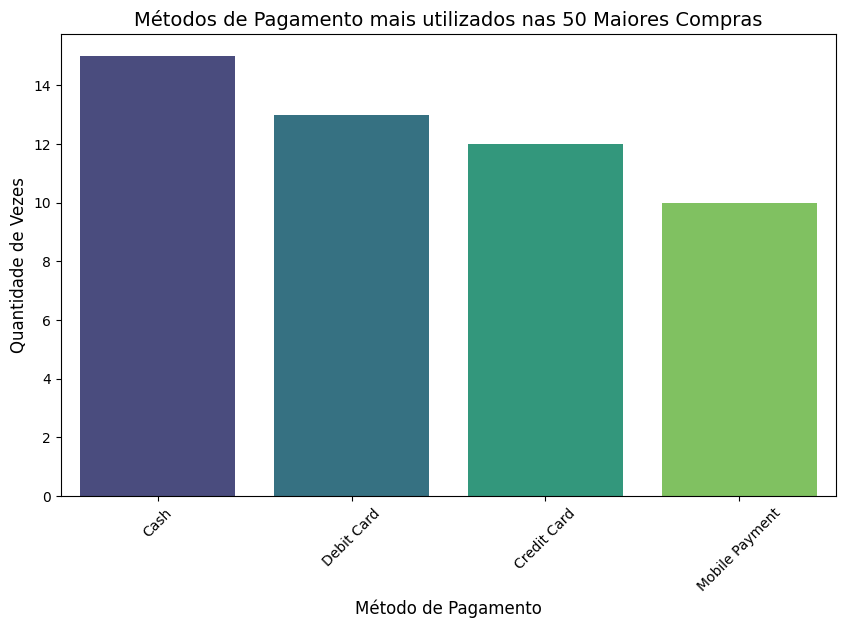

In [18]:
#Importação das bibliotecas para visualização
import matplotlib.pyplot as plt 
import seaborn as sns 

#Filtrando 50 compras mais caras
top_50_compras = df_varejo.nlargest(50, "Total_Cost")

#Criando o gráfico
plt.figure(figsize=(10, 6))
sns.countplot(data=top_50_compras, x="Payment_Method", palette="viridis", 
              order=top_50_compras["Payment_Method"].value_counts().index)

#Customização do gráfico
plt.title("Métodos de Pagamento mais utilizados nas 50 Maiores Compras", fontsize=14)
plt.xlabel("Método de Pagamento", fontsize=12)
plt.ylabel("Quantidade de Vezes", fontsize=12)
plt.xticks(rotation=45) # Rotaciona os nomes para não embolar
plt.show()

In [19]:
metodo_top50 = top_50_compras['Payment_Method'].value_counts()
print(f"Método mais usado nas 50 maiores compras: {metodo_top50.idxmax()} ({metodo_top50.max()} vezes)")

Método mais usado nas 50 maiores compras: Cash (15 vezes)


In [20]:
#Qual a quantidade de vendas por hora.
df_varejo['Date'] = pd.to_datetime(df_varejo['Date'])

#Extraindo apenas a hora
df_varejo['Hour'] = df_varejo['Date'].dt.hour

#Contando a quantidade de vendas por hora
df_varejo['Hour'].value_counts().sort_values(ascending=False)


Hour
10    42021
8     41926
3     41917
21    41894
18    41843
9     41841
15    41819
13    41817
12    41790
4     41768
14    41739
23    41698
20    41674
17    41655
19    41646
2     41617
5     41574
7     41521
6     41508
16    41505
22    41433
0     41416
1     41224
11    41154
Name: count, dtype: int64

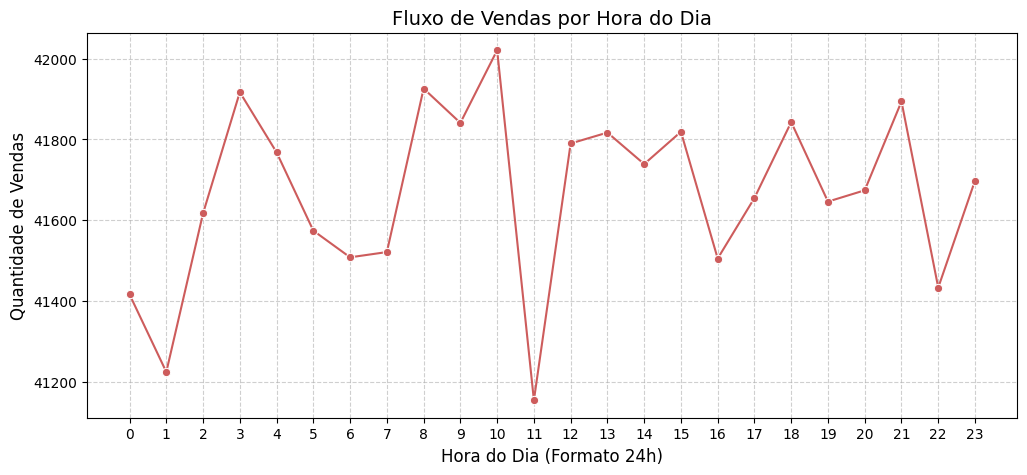

In [21]:
#Criando a contagem ordenada pelas horas do dia (0 a 23)
contagem_horas = df_varejo['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=contagem_horas.index, y=contagem_horas.values, marker='o', color='indianred')

plt.title('Fluxo de Vendas por Hora do Dia', fontsize=14)
plt.xlabel('Hora do Dia (Formato 24h)', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)
plt.xticks(range(0, 24)) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [22]:
#Qual a quantidade de vendas por dia da semana
df_varejo['Date'] = pd.to_datetime(df_varejo['Date'])

#Cria a coluna com o nome do dia da semana
df_varejo['Day_of_Week'] = df_varejo['Date'].dt.day_name()

#Visualizando as primeiras linhas para conferir
print(df_varejo[['Date', 'Day_of_Week']].head())

print("--------------------------------------")

vendas_por_dia = df_varejo['Day_of_Week'].value_counts()
print(vendas_por_dia)


                 Date Day_of_Week
0 2022-01-21 06:27:29      Friday
1 2023-03-01 13:01:21   Wednesday
2 2024-03-21 15:37:04    Thursday
3 2020-10-31 09:59:47    Saturday
4 2020-12-10 00:59:59    Thursday
--------------------------------------
Day_of_Week
Thursday     143375
Friday       143367
Saturday     143310
Wednesday    143104
Monday       142435
Tuesday      142317
Sunday       142092
Name: count, dtype: int64


C:\Users\SarahCavalcanteSalvi\AppData\Local\Temp\ipykernel_16284\3190340536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_dias.index, y=contagem_dias.values, palette='viridis')


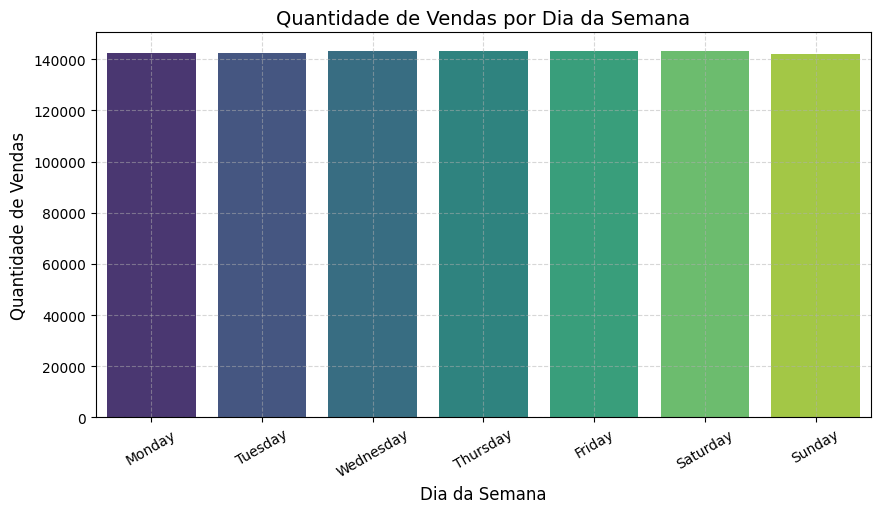

In [23]:
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
contagem_dias = df_varejo['Day_of_Week'].value_counts().reindex(ordem_dias)

plt.figure(figsize=(10, 5))
sns.barplot(x=contagem_dias.index, y=contagem_dias.values, palette='viridis')
plt.title('Quantidade de Vendas por Dia da Semana', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Quantidade de Vendas', fontsize=12)
plt.xticks(rotation=30)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [24]:
#Formata a data para o padrão DD/MM/AAAA
df_varejo['Data_Formatada'] = df_varejo['Date'].dt.strftime('%d/%m/%Y')

#Agrupa e conta
contagem = df_varejo.groupby(['City', 'Data_Formatada', 'Day_of_Week', 'Hour']).size().reset_index(name='Qtd_Vendas')

#Pega o recorde de cada cidade
resultado = contagem.loc[contagem.groupby('City')['Qtd_Vendas'].idxmax()]

print(resultado[['City', 'Qtd_Vendas', 'Hour', 'Data_Formatada', 'Day_of_Week']])

                 City  Qtd_Vendas  Hour Data_Formatada Day_of_Week
14244         Atlanta          11    21     13/02/2023      Monday
41458          Boston          13    21     06/02/2020    Thursday
72080         Chicago          11     1     01/11/2022     Tuesday
119305         Dallas          11    11     11/09/2023      Monday
157462        Houston          12     9     13/12/2020      Sunday
186786    Los Angeles          13    14     08/08/2021      Sunday
227451          Miami          12    16     13/01/2022    Thursday
270416       New York          12     5     19/04/2020      Sunday
292499  San Francisco          11    11     07/10/2023    Saturday
322225        Seattle          11     0     02/12/2020   Wednesday


In [25]:
#Filtrando apenas as vendas de Atlanta no dia e hora do recorde para conferir
conferência = df_varejo[
    (df_varejo['City'] == 'Atlanta') & 
    (df_varejo['Data_Formatada'] == '13/02/2023') & 
    (df_varejo['Hour'] == 21)
]

print(f"Total de linhas encontradas: {len(conferência)}")

Total de linhas encontradas: 11


## Setor escolhido: Department Store

In [26]:
#Separando apenas as informações do setor de Department Store
df_dept = df_varejo[df_varejo['Store_Type'] == 'Department Store'].copy()

#print(f'Total de registros no setor: {len(df_dept)}')
print(df_dept.head())

    Transaction_ID                Date    Customer_Name  \
2       1000000002 2024-03-21 15:37:04      Lisa Graves   
10      1000000010 2020-03-18 18:58:18  Randall Roberts   
17      1000000017 2021-09-16 09:28:28     Vanessa Peck   
19      1000000019 2021-01-31 07:52:18   Charles Brooks   
21      1000000021 2022-12-30 20:03:19     John Roberts   

                                              Product  Total_Items  \
2                                         ['Spinach']            6   
10  ['Extension Cords', 'Soda', 'Water', 'Garden H...            8   
17  ['Power Strips', 'Honey', 'Ketchup', 'Tea', 'S...            8   
19                                         ['Coffee']            7   
21                        ['Coffee', 'Shaving Cream']            1   

    Total_Cost Payment_Method           City        Store_Type  \
2        41.49    Credit Card        Houston  Department Store   
10       91.59     Debit Card         Boston  Department Store   
17       15.62    Credit C

In [27]:
print(len(df_dept))

166614


In [28]:
#Criando a coluna de df_items para separar os produtos
df_items = df_dept.copy()
df_items['Product'] = df_items['Product'].str.split(',') 

df_items = df_items.explode('Product')

df_items['Product'] = df_items['Product'].str.strip()

In [29]:
df_items

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Hour,Day_of_Week,Data_Formatada
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN,15,Thursday,21/03/2024
10,1000000010,2020-03-18 18:58:18,Randall Roberts,['Extension Cords',8,91.59,Debit Card,Boston,Department Store,True,Middle-Aged,Fall,BOGO (Buy One Get One),18,Wednesday,18/03/2020
10,1000000010,2020-03-18 18:58:18,Randall Roberts,'Soda',8,91.59,Debit Card,Boston,Department Store,True,Middle-Aged,Fall,BOGO (Buy One Get One),18,Wednesday,18/03/2020
10,1000000010,2020-03-18 18:58:18,Randall Roberts,'Water',8,91.59,Debit Card,Boston,Department Store,True,Middle-Aged,Fall,BOGO (Buy One Get One),18,Wednesday,18/03/2020
10,1000000010,2020-03-18 18:58:18,Randall Roberts,'Garden Hose',8,91.59,Debit Card,Boston,Department Store,True,Middle-Aged,Fall,BOGO (Buy One Get One),18,Wednesday,18/03/2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999989,1000999989,2020-09-30 04:13:03,Bonnie Hughes,'Mayonnaise',8,49.01,Debit Card,Miami,Department Store,False,Retiree,Summer,NaN,4,Wednesday,30/09/2020
999989,1000999989,2020-09-30 04:13:03,Bonnie Hughes,'Soda'],8,49.01,Debit Card,Miami,Department Store,False,Retiree,Summer,NaN,4,Wednesday,30/09/2020
999991,1000999991,2021-08-30 04:16:07,Jamie Nunez,['Jam',8,28.07,Mobile Payment,Los Angeles,Department Store,False,Retiree,Winter,NaN,4,Monday,30/08/2021
999991,1000999991,2021-08-30 04:16:07,Jamie Nunez,'Cleaning Spray',8,28.07,Mobile Payment,Los Angeles,Department Store,False,Retiree,Winter,NaN,4,Monday,30/08/2021


In [30]:
#Removendo colchetes, aspas simples e espaços
df_items['Product'] = df_items['Product'].str.replace(r"[\[\]']", "", regex=True).str.strip()

#Pegando os produtos únicos de verdade
produtos_limpos = sorted(df_items['Product'].unique())

#Mostrando a quantidade real e a lista.
print(f"O setor tem {len(produtos_limpos)} produtos únicos.")
print("-" * 30)
for p in produtos_limpos[:81]: 
    print(f"- {p}")

O setor tem 81 produtos únicos.
------------------------------
- Air Freshener
- Apple
- BBQ Sauce
- Baby Wipes
- Banana
- Bath Towels
- Beef
- Bread
- Broom
- Butter
- Canned Soup
- Carrots
- Cereal
- Cereal Bars
- Cheese
- Chicken
- Chips
- Cleaning Rags
- Cleaning Spray
- Coffee
- Deodorant
- Diapers
- Dish Soap
- Dishware
- Dustpan
- Eggs
- Extension Cords
- Feminine Hygiene Products
- Garden Hose
- Hair Gel
- Hand Sanitizer
- Honey
- Ice Cream
- Insect Repellent
- Iron
- Ironing Board
- Jam
- Ketchup
- Laundry Detergent
- Lawn Mower
- Light Bulbs
- Mayonnaise
- Milk
- Mop
- Mustard
- Olive Oil
- Onions
- Orange
- Pancake Mix
- Paper Towels
- Pasta
- Peanut Butter
- Pickles
- Plant Fertilizer
- Potatoes
- Power Strips
- Razors
- Rice
- Salmon
- Shampoo
- Shaving Cream
- Shower Gel
- Shrimp
- Soap
- Soda
- Spinach
- Sponges
- Syrup
- Tea
- Tissues
- Toilet Paper
- Tomatoes
- Toothbrush
- Toothpaste
- Trash Bags
- Trash Cans
- Tuna
- Vacuum Cleaner
- Vinegar
- Water
- Yogurt


In [31]:
#Qual o método de pagamento mais usado no setor de Department Store.

df_dept.value_counts("Payment_Method")

Payment_Method
Mobile Payment    41834
Credit Card       41671
Cash              41656
Debit Card        41453
Name: count, dtype: int64

In [32]:
#Qual o total de custo por cidade.

df_dept.groupby('City')['Total_Cost'].sum().sort_values(ascending=False)

City
Dallas           888924.78
San Francisco    886476.22
Boston           884090.59
New York         877227.20
Miami            872548.05
Atlanta          867943.81
Los Angeles      866455.38
Houston          866049.75
Chicago          861565.49
Seattle          860274.30
Name: Total_Cost, dtype: float64

In [33]:
#Qual item mais vendeu no setor.
mais_vendido = df_items['Product'].value_counts().idxmax()
qtd_mais = df_items['Product'].value_counts().max()

#Qual item menos vendeu
menos_vendido = df_items['Product'].value_counts().idxmin()
qtd_menos = df_items['Product'].value_counts().min()

#Qual item cada perfil de cliente compra mais.
ranking_perfil = df_items.groupby(['Customer_Category', 'Product']).size().reset_index(name='Contagem')
ranking_perfil = ranking_perfil.sort_values(['Customer_Category', 'Contagem'], ascending=[True, False])
top_por_perfil = ranking_perfil.groupby('Customer_Category').head(1)

print(f"O campeão de vendas é: {mais_vendido} ({qtd_mais} unidades)")
print(f"O que menos saiu foi: {menos_vendido} ({qtd_menos} unidades)")
print("\n--- Top 1 por Perfil de Cliente ---")
print(top_por_perfil)

O campeão de vendas é: Toothpaste (12220 unidades)
O que menos saiu foi: Vacuum Cleaner (5957 unidades)

--- Top 1 por Perfil de Cliente ---
    Customer_Category     Product  Contagem
73          Homemaker  Toothpaste      1518
154       Middle-Aged  Toothpaste      1531
235      Professional  Toothpaste      1510
316           Retiree  Toothpaste      1521
397    Senior Citizen  Toothpaste      1560
478           Student  Toothpaste      1446
559          Teenager  Toothpaste      1495
640       Young Adult  Toothpaste      1639


In [34]:
df_items['Product'].unique()


<ArrowStringArray>
[                  'Spinach',           'Extension Cords',
                      'Soda',                     'Water',
               'Garden Hose',            'Cleaning Spray',
              'Power Strips',                     'Honey',
                   'Ketchup',                       'Tea',
                   'Shampoo',                    'Coffee',
             'Shaving Cream',                  'Dishware',
                   'Pickles',                    'Razors',
                     'Chips', 'Feminine Hygiene Products',
                     'Bread',                   'Dustpan',
             'Ironing Board',                      'Beef',
                      'Milk',                    'Salmon',
                      'Tuna',                     'Broom',
               'Pancake Mix',         'Laundry Detergent',
               'Cereal Bars',             'Air Freshener',
                    'Banana',                'Toothpaste',
                     'Syrup',        

## Modelo escolhido: FP_Growth

In [35]:
pip install pyfpgrowth

Note: you may need to restart the kernel to use updated packages.


In [36]:
import pyfpgrowth

In [53]:
#Criando as transações

import ast #Converte strings que parecem listas em listas de verdade

df_items2 = df_dept.copy().reset_index(drop=False).rename(columns={'index': 'transaction_id'})

# Converte a string "['item1', 'item2']" em lista Python de verdade
df_items2['Product'] = df_items2['Product'].apply(ast.literal_eval)

#Aplicando explode para transformar cada item em uma linha separada
df_items2 = df_items2.explode('Product')
df_items2['Product'] = df_items2['Product'].str.strip()

transacoes2 = df_items2.groupby('transaction_id')['Product'].apply(list).tolist() #Pegando de volta os produtos que ficaram individualizados e transformando em uma lista de transação só

print(f"Total de transações: {len(transacoes2)}")
print(f"Exemplo: {transacoes2[0]}")

Total de transações: 166614
Exemplo: ['Spinach']


In [54]:
#Aplicando o algoritmo FP-Growth para encontrar os padrões frequentes com suporte mínimo de 50 transações
padroes = pyfpgrowth.find_frequent_patterns(transacoes2, 50) #Essa linha faz com que o resultado seja um dicionário onde a chave é o id da transação e o valor é quantas vezes esse padrão apareceu, também está sendo aplicado um suporte mínimo de 50.

print(f"Total de padrões encontrados: {len(padroes)}")

Total de padrões encontrados: 3322


In [39]:
import sys
!{sys.executable} -m pip install mlxtend 

  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.


In [40]:
import sys
!{sys.executable} -m pip install "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.2 which is incompatible.


In [41]:
import sys
!{sys.executable} -m pip install "numpy<2" "pyarrow>=17.0.0" scikit-learn --upgrade

In [55]:
#Usando mlxtend para gerar os padrões e regras
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

#Transformando as transações no formato que o mlxtend precisa
te = TransactionEncoder() #No mlxtend o formato dos dados precisa ser uma matriz binária, aonde cada coluna é um produto e cada linha é uma transação com true ou false indicando se o produto está presente ou não na transação
te_array = te.fit(transacoes2).transform(transacoes2)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

#Rodando o FP-Growth
padroes_ml = fpgrowth(df_encoded, min_support=0.001, use_colnames=True) #O suporte mínimo de 0.001 significa que o padrão precisa aparecer em pelo menos 0.1% das transações para ser considerado frequente

#Gerando as regras
regras_ml = association_rules(padroes_ml, metric="confidence", min_threshold=0.01) #Gerando as regras a partid dos padrões encontrados, com um limiar mínimo de confiança de 0.01 (1%)

print(f"Padrões: {len(padroes_ml)}")
print(f"Regras: {len(regras_ml)}")
print(regras_ml[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Padrões: 3237
Regras: 6312
                              antecedents  \
0                    frozenset({Spinach})   
1                 frozenset({Toothpaste})   
2                    frozenset({Sponges})   
3                    frozenset({Spinach})   
4                   frozenset({Hair Gel})   
5                    frozenset({Spinach})   
6                    frozenset({Spinach})   
7  frozenset({Feminine Hygiene Products})   
8           frozenset({Plant Fertilizer})   
9                    frozenset({Spinach})   

                              consequents   support  confidence      lift  
0                 frozenset({Toothpaste})  0.002029    0.057512  0.810416  
1                    frozenset({Spinach})  0.002029    0.028586  0.810416  
2                    frozenset({Spinach})  0.001182    0.032380  0.917979  
3                    frozenset({Sponges})  0.001182    0.033521  0.917979  
4                    frozenset({Spinach})  0.001158    0.032076  0.909354  
5                   f

In [ ]:
#TESTE AUMENTANDO SUPORTE MINIMO E CONFIANÇA.
#Usando mlxtend para gerar os padrões e regras
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

#Transformando as transações no formato que o mlxtend precisa
te = TransactionEncoder() #No mlxtend o formato dos dados precisa ser uma matriz binária, aonde cada coluna é um produto e cada linha é uma transação com true ou false indicando se o produto está presente ou não na transação
te_array = te.fit(transacoes2).transform(transacoes2)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

#Rodando o FP-Growth
padroes_ml = fpgrowth(df_encoded, min_support=0.005, use_colnames=True) #O suporte mínimo de 0.005 significa que o padrão precisa aparecer em pelo menos 0.5% das transações para ser considerado frequente

#Gerando as regras
regras_ml = association_rules(padroes_ml, metric="confidence", min_threshold=0.05) #Gerando as regras a partid dos padrões encontrados, com um limiar mínimo de confiança de 0.01 (1%)

print(f"Padrões: {len(padroes_ml)}")
print(f"Regras: {len(regras_ml)}")
print(regras_ml[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Padrões: 81
Regras: 0
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [56]:
#Filtrando só regras com lift > 1 
regras_fortes = regras_ml[regras_ml['lift'] > 1].sort_values('confidence', ascending=False) #Lift menor ou igual a 1 pode indicar coincidência ou que os produtos se repelem, ou seja, não tem uma associação real entre eles

print(f"Regras com lift > 1: {len(regras_fortes)}")
print(regras_fortes[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Regras com lift > 1: 300
                     antecedents                 consequents   support  \
5041          frozenset({Apple})     frozenset({Toothpaste})  0.002551   
4737  frozenset({Cleaning Rags})       frozenset({Tomatoes})  0.001458   
4382         frozenset({Cheese})        frozenset({Mustard})  0.001464   
152     frozenset({Garden Hose})          frozenset({Water})  0.001464   
4736       frozenset({Tomatoes})  frozenset({Cleaning Rags})  0.001458   
4383        frozenset({Mustard})         frozenset({Cheese})  0.001464   
153           frozenset({Water})    frozenset({Garden Hose})  0.001464   
1523        frozenset({Dustpan})         frozenset({Cereal})  0.001398   
5381        frozenset({Diapers})  frozenset({Air Freshener})  0.001404   
1522         frozenset({Cereal})        frozenset({Dustpan})  0.001398   

      confidence      lift  
5041    0.072501  1.021622  
4737    0.040669  1.118538  
4382    0.040518  1.109430  
152     0.040277  1.093849  
4736    0.04011

In [ ]:
#TESTE AUMENTANDO SUPORTE MINIMO E CONFIANÇA.
#Filtrando só regras com lift > 1 
regras_fortes = regras_ml[regras_ml['lift'] > 1].sort_values('confidence', ascending=False) #Lift menor ou igual a 1 pode indicar coincidência ou que os produtos se repelem, ou seja, não tem uma associação real entre eles

print(f"Regras com lift > 1: {len(regras_fortes)}")
print(regras_fortes[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Regras com lift > 1: 0
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [44]:
#Exibindo as regras

#Transformando as colunas de antecedents e consequents de frozenset para string legível
regras_fortes['antecedents'] = regras_fortes['antecedents'].apply(lambda x: ', '.join(list(x)))
regras_fortes['consequents'] = regras_fortes['consequents'].apply(lambda x: ', '.join(list(x)))

print("=== Exemplo com 10 regras de associação - Department Store ===\n")
for _, row in regras_fortes.head(10).iterrows():
    print(f"Se comprou '{row['antecedents']}' → tende a comprar '{row['consequents']}'")
    print(f"   Suporte: {row['support']:.2%} | Confiança: {row['confidence']:.2%} | Lift: {row['lift']:.2f}\n")

=== Exemplo com 10 regras de associação - Department Store ===

Se comprou 'Apple' → tende a comprar 'Toothpaste'
   Suporte: 0.26% | Confiança: 7.25% | Lift: 1.02

Se comprou 'Cleaning Rags' → tende a comprar 'Tomatoes'
   Suporte: 0.15% | Confiança: 4.07% | Lift: 1.12

Se comprou 'Cheese' → tende a comprar 'Mustard'
   Suporte: 0.15% | Confiança: 4.05% | Lift: 1.11

Se comprou 'Garden Hose' → tende a comprar 'Water'
   Suporte: 0.15% | Confiança: 4.03% | Lift: 1.09

Se comprou 'Tomatoes' → tende a comprar 'Cleaning Rags'
   Suporte: 0.15% | Confiança: 4.01% | Lift: 1.12

Se comprou 'Mustard' → tende a comprar 'Cheese'
   Suporte: 0.15% | Confiança: 4.01% | Lift: 1.11

Se comprou 'Water' → tende a comprar 'Garden Hose'
   Suporte: 0.15% | Confiança: 3.98% | Lift: 1.09

Se comprou 'Dustpan' → tende a comprar 'Cereal'
   Suporte: 0.14% | Confiança: 3.94% | Lift: 1.10

Se comprou 'Diapers' → tende a comprar 'Air Freshener'
   Suporte: 0.14% | Confiança: 3.91% | Lift: 1.08

Se comprou 'Ce

In [45]:
top20_lift = regras_fortes.sort_values('lift', ascending=False).head(20)
print(top20_lift[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))

  antecedents   consequents  support  confidence     lift
     Tomatoes Cleaning Rags 0.001458    0.040112 1.118538
Cleaning Rags      Tomatoes 0.001458    0.040669 1.118538
       Cheese       Mustard 0.001464    0.040518 1.109430
      Mustard        Cheese 0.001464    0.040099 1.109430
      Dustpan        Cereal 0.001398    0.039385 1.098618
       Cereal       Dustpan 0.001398    0.039009 1.098618
  Garden Hose         Water 0.001464    0.040277 1.093849
        Water   Garden Hose 0.001464    0.039772 1.093849
      Vinegar          Tuna 0.001362    0.038190 1.079931
         Tuna       Vinegar 0.001362    0.038527 1.079931
      Diapers Air Freshener 0.001404    0.039144 1.078172
Air Freshener       Diapers 0.001404    0.038684 1.078172
       Orange          Milk 0.001392    0.038545 1.072490
         Milk        Orange 0.001392    0.038744 1.072490
      Chicken        Banana 0.001374    0.038656 1.072018
       Banana       Chicken 0.001374    0.038116 1.072018
      Sponges 

## Conclusões

O modelo FP-Growth identificou **300 regras** com associação real (lift > 1). 
Para esta análise foram selecionadas as **20 regras com maior lift**, 
que resultaram em **10 associações bidirecionais**.

# Associações Bidirecionais Identificadas

- **Tomatoes ↔ Cleaning Rags** (lift: 1.12): Pode indicar um perfil de cliente 
  que cozinha com frequência e naturalmente necessita de panos de limpeza.

- **Cheese ↔ Mustard** (lift: 1.11): Associação clássica de produtos 
  complementares, pode sugerir posicionamento próximo na loja ou promoção combinada. 
  Ambos podem ser associados pelo uso em comum, como a preparação de lanches, já que logo alguém que pensa em fazer um lanche, pode pensar automaticamente em um molho para acompanhar.

- **Dustpan ↔ Cereal** (lift: 1.10): Associação inusitada, sem relação direta 
  entre os produtos. Pode indicar clientes que fazem compras mensais completas, 
  aproveitando para levar tanto utensílios domésticos quanto alimentos.

- **Garden Hose ↔ Water** (lift: 1.09): Produtos complementares dentro do 
  contexto de jardinagem. Boa oportunidade de cross-sell, já que se complementam 
  naturalmente na mesma finalidade.

- **Vinegar ↔ Tuna** (lift: 1.08): Possível associação culinária, o vinagre 
  é amplamente usado na limpeza e no preparo de peixes, eliminando odores fortes 
  e bactérias.

- **Diapers ↔ Air Freshener** (lift: 1.08): Perfil provável de pais com filhos 
  pequenos que também mantêm a limpeza da casa.

- **Orange ↔ Milk** (lift: 1.07): Indica compras semanais de perecíveis,  
  ambos têm prazo de validade curto e tendem a ser comprados juntos na mesma ida 
  ao mercado.

- **Chicken ↔ Banana** (lift: 1.07): Reforça o padrão de compra semanal 
  de alimentos frescos.

- **Sponges ↔ Soap** (lift: 1.06): Associação altamente intuitiva, esponja 
  e sabão são produtos de limpeza complementares, representando uma forte 
  oportunidade de cross-sell.

- **Shaving Cream ↔ Razors** (lift: 1.06): Associação direta de produtos 
  de higiene pessoal. Quem compra um naturalmente precisa do outro, sendo 
  outra oportunidade clara de cross-sell.

# Perfis

Das 10 associações identificadas, é possível agrupar em 3 perfis:

- **Cross-sell direto** (produtos que se complementam na mesma finalidade): 
  Sponges/Soap, Shaving Cream/Razors, Garden Hose/Water
- **Perfil culinário** (produtos associados pelo uso na cozinha): 
  Cheese/Mustard, Vinegar/Tuna, Tomatoes/Cleaning Rags
- **Compra semanal** (produtos perecíveis ou domésticos comprados juntos): 
  Orange/Milk, Chicken/Banana, Diapers/Air Freshener, Dustpan/Cereal

C:\Users\SarahCavalcanteSalvi\AppData\Local\Temp\ipykernel_16284\2216700400.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


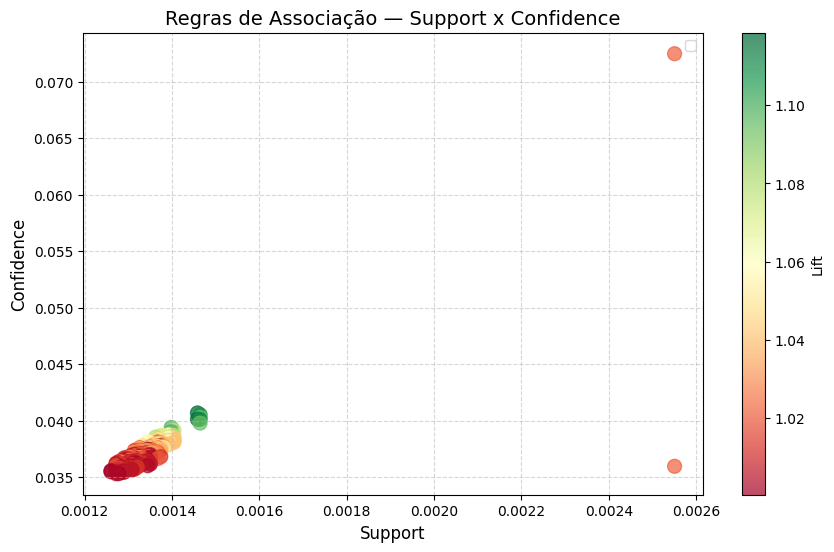

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    regras_fortes['support'], 
    regras_fortes['confidence'],
    c=regras_fortes['lift'], 
    cmap='RdYlGn', 
    alpha=0.7,
    s=100
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Regras de Associação — Support x Confidence', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

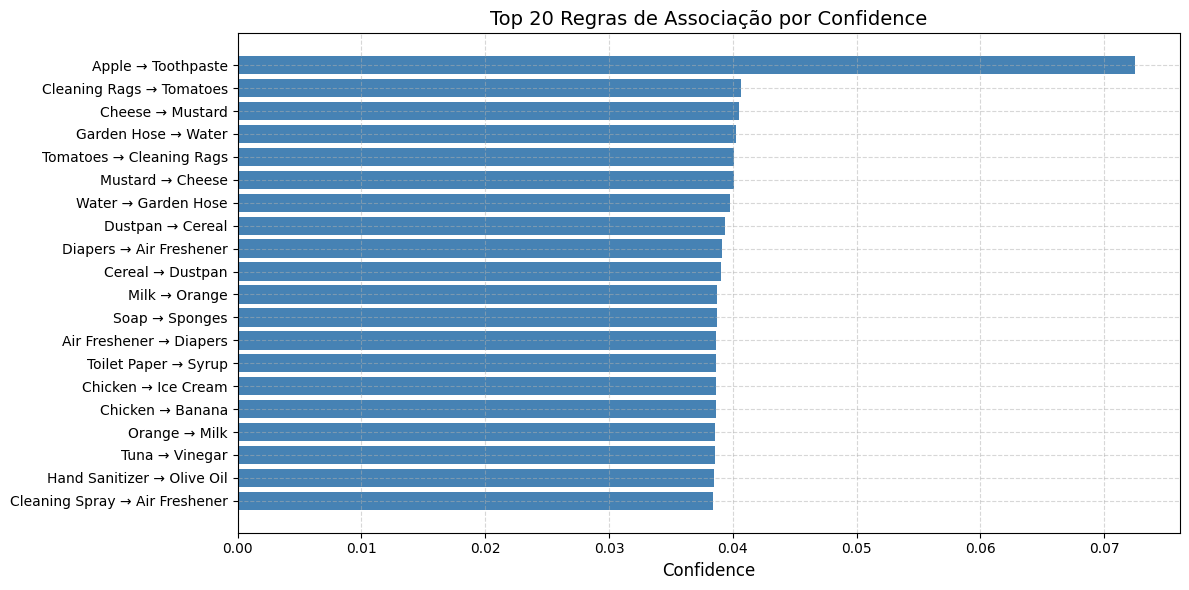

In [63]:
top_lift = regras_fortes.head(20).copy()
top_lift['antecedents'] = top_lift['antecedents'].apply(lambda x: ', '.join(list(x)))
top_lift['consequents'] = top_lift['consequents'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(12, 6))
labels = top_lift['antecedents'] + ' → ' + top_lift['consequents']
plt.barh(labels, top_lift['confidence'], color='steelblue')

plt.xlabel('Confidence', fontsize=12)
plt.title('Top 20 Regras de Associação por Confidence', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Métricas de Avaliação do Modelo

Para algoritmos de regras de associação como o FP-Growth, as métricas de 
avaliação são diferentes de modelos de classificação (como acurácia, F1, recall).
Isso porque o FP-Growth não prevê classes e sim descobre padrões. As métricas usadas foram:

- **Support**: frequência com que um conjunto de itens aparece no dataset.
  Usado para filtrar padrões raros e pouco relevantes.

- **Confidence**: dado que o cliente comprou o item A, qual a probabilidade 
  de comprar o item B. Mede a força da regra.

- **Lift**: indica se a associação entre os itens é real ou coincidência.
  - Lift < 1 → os itens se repelem
  - Lift = 1 → os itens são independentes
  - Lift > 1 → existe associação real

O **Lift foi a métrica principal** de avaliação, pois elimina associações 
espúrias e garante que as regras encontradas têm valor de negócio real.